# lexicon Retrieval Method Ablation Study

**Research Analysis**: Comprehensive evaluation of different lexicon retrieval methods for retrieval-augmented LLM post-editing in Bible translation.

**Methods Evaluated**:
- **Full lexicon**: Uses the complete lexicon (2377 entries)
- **Fuzzy Word Matching Matching**: Retrieves n examples per word in source sentence
  - n ∈ {3, 5, 10, 15, 20, 25, 30, 50, 70, 100}


In [7]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Research paper styling
plt.style.use('default')
sns.set_palette("Set2")  # Professional color palette
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'serif'  # Better for publications
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.alpha'] = 0.3

print("Research analysis environment ready.")


Research analysis environment ready.


## 1. Data Loading and Preprocessing


In [ ]:
def load_lexicon_data():
    """Load all lexicon retrieval ablation results"""
    
    base_path = Path("/Users/davidsamuel/Documents/Unimelb Masters/Thesis/bible-nmt")
    lexicon_path = base_path / "results" / "gemini-2.5-flash-webp-dhao"
    
    all_data = []
    
    # Define the subdirectories to load
    lexicon_dirs = [
        ('lexicon_full', 'Full', 2377, 'gemini-2.5-flash_aligned-eng-engwebp-ot_eng_nfa_metrics.json'),
        ('lexicon_n3', 'Fuzzy Word Matching', 3, 'gemini-2.5-flash_aligned-eng-engwebp-ot_eng_nfa_metrics.json'),
        ('lexicon_n5', 'Fuzzy Word Matching', 5, 'gemini-2.5-flash_aligned-eng-engwebp-ot_eng_nfa_metrics.json'),
        ('lexicon_n10', 'Fuzzy Word Matching', 10, 'gemini-2.5-flash_aligned-eng-engwebp-ot_eng_nfa_metrics.json'),
        ('lexicon_n15', 'Fuzzy Word Matching', 15, 'gemini-2.5-flash_aligned-eng-engwebp-ot_eng_nfa_metrics.json'),
        ('lexicon_n20', 'Fuzzy Word Matching', 20, 'gemini-2.5-flash_aligned-eng-engwebp-ot_eng_nfa_metrics.json'),
        ('lexicon_n25', 'Fuzzy Word Matching', 25, 'gemini-2.5-flash_aligned-eng-engwebp-ot_eng_nfa_metrics.json'),
        ('lexicon_n30', 'Fuzzy Word Matching', 30, 'gemini-2.5-flash_aligned-eng-engwebp-ot_eng_nfa_metrics.json'),
        ('lexicon_n50', 'Fuzzy Word Matching', 50, 'gemini-2.5-flash_aligned-eng-engwebp-ot_eng_nfa_metrics.json'),
        ('lexicon_n70', 'Fuzzy Word Matching', 70, 'gemini-2.5-flash_aligned-eng-engwebp-ot_eng_nfa_metrics.json'),
        ('lexicon_n100', 'Fuzzy Word Matching', 100, 'gemini-2.5-flash_aligned-eng-engwebp-ot_eng_nfa_metrics.json'),
    ]
    
    for dir_name, method_type, parameter, metrics_file in lexicon_dirs:
        metrics_path = lexicon_path / dir_name / metrics_file
        
        if metrics_path.exists():
            with open(metrics_path, 'r') as f:
                metrics = json.load(f)
            all_data.extend(parse_metrics(metrics, dir_name, method_type, parameter))
        else:
            print(f"Warning: {metrics_path} not found")
    
    return pd.DataFrame(all_data)

def parse_metrics(metrics, method_name, method_type, parameter):
    """Parse metrics JSON into structured data"""
    data = []
    
    original = metrics['original_mt_metrics']
    post_edited = metrics['post_edited_metrics']
    improvements = metrics['improvements']
    
    # Average sentence length from the dataset (25.59 words/sentence)
    avg_words_per_sentence = 25.59
    
    for metric in original.keys():
        # Calculate effective examples for Fuzzy Word Matching method
        if method_type == 'Fuzzy Word Matching':
            effective_k = parameter * avg_words_per_sentence
        elif method_type == 'Full':
            effective_k = parameter  # 2377 total entries
        else:  # No lexicon
            effective_k = 0
        
        data.append({
            'method_name': method_name,
            'method_type': method_type,
            'parameter': parameter,
            'metric': metric,
            'original_score': original[metric],
            'post_edited_score': post_edited[metric],
            'improvement': improvements[metric],
            'effective_k': effective_k
        })
    
    return data

# Load data
df = load_lexicon_data()

print(f"Loaded {len(df)} data points")
print(f"Methods: {df['method_type'].unique()}")
print(f"Metrics: {df['metric'].unique()}")
print(f"\nParameters per method:")
for method in df['method_type'].unique():
    params = sorted(df[df['method_type']==method]['parameter'].unique())
    print(f"  {method}: {params}")


Loaded 66 data points
Methods: ['Full' 'Fuzzy Word Matching']
Metrics: ['bleu' 'sacrebleu' 'spbleu' 'chrf' 'chrf3' 'chrf++']

Parameters per method:
  Full: [2377]
  Fuzzy Word Matching: [3, 5, 10, 15, 20, 25, 30, 50, 70, 100]


## 2. Summary Table: Method Performance Comparison


In [ ]:
# Filter to keep only spBLEU and chrF++ metrics
df_filtered = df[df['metric'].isin(['spbleu', 'chrf++'])].copy()

print(f"Filtering to spBLEU and chrF++ only:")
print(f"Original data points: {len(df)}")
print(f"Filtered data points: {len(df_filtered)}")

# Create results table with baseline and improvements
results_rows = []

# Get baseline scores (from nllb-200-distilled-600M_NT)
baseline_spbleu = df_filtered[df_filtered['metric'] == 'spbleu']['original_score'].iloc[0]
baseline_chrf = df_filtered[df_filtered['metric'] == 'chrf++']['original_score'].iloc[0]

# Add baseline row
results_rows.append({
    'Method': 'nllb-200-distilled-600M_NT',
    'n_shot': '~',
    'spBLEU': f"{baseline_spbleu:.2f}",
    'chrF++': f"{baseline_chrf:.2f}"
})

# Pivot the filtered dataframe to have metrics as columns
df_wide = df_filtered.pivot_table(
    index=['method_name', 'method_type', 'parameter', 'effective_k'],
    columns='metric',
    values=['post_edited_score', 'improvement'],
    aggfunc='first'
).reset_index()

# Flatten column names
df_wide.columns = ['_'.join(col).strip('_') if col[1] else col[0] for col in df_wide.columns.values]

# Create the n_shot column with formatting
def format_n_shot(row):
    if row['method_type'] == 'No lexicon':
        return '~'
    elif row['method_type'] == 'Fuzzy Word Matching':
        return f"{int(row['parameter'])} (≈{int(row['effective_k'])})"
    else:  # Full
        return str(int(row['parameter']))

df_wide['n_shot'] = df_wide.apply(format_n_shot, axis=1)

# Calculate average improvement for sorting
df_wide['avg_improvement'] = (df_wide['improvement_spbleu'] + df_wide['improvement_chrf++']) / 2

# Sort by average improvement descending
df_wide = df_wide.sort_values('avg_improvement', ascending=False)

# Add formatted rows with improvements
for _, row in df_wide.iterrows():
    results_rows.append({
        'Method': row['method_type'],
        'n_shot': row['n_shot'],
        'spBLEU': f"{row['post_edited_score_spbleu']:.2f} (+{row['improvement_spbleu']:.2f})",
        'chrF++': f"{row['post_edited_score_chrf++']:.2f} (+{row['improvement_chrf++']:.2f})"
    })

# Create final dataframe
df_result = pd.DataFrame(results_rows)


# Display as styled table
df_result.to_csv("lexicon_ablation_results.csv")


Filtering to spBLEU and chrF++ only:
Original data points: 66
Filtered data points: 22


## 3. Correlation Analysis: K Values vs Performance


In [4]:
# Calculate average improvement per configuration (average of spBLEU and chrF++)
df_analysis = df[df['metric'].isin(['spbleu', 'chrf++'])].copy()
avg_improvement_per_config = df_analysis.groupby(['method_name', 'method_type', 'parameter', 'effective_k'])['improvement'].mean().reset_index()
avg_improvement_per_config.rename(columns={'improvement': 'overall_improvement'}, inplace=True)

print("="*80)
print("CORRELATION ANALYSIS: K Values vs Overall Improvement (spBLEU + chrF++)")
print("="*80)

# Calculate correlation for Fuzzy Word Matching method
fuzzy_data = avg_improvement_per_config[avg_improvement_per_config['method_type'] == 'Fuzzy Word Matching']
if len(fuzzy_data) > 1:
    correlation = fuzzy_data['parameter'].corr(fuzzy_data['overall_improvement'])
    print(f"\nFuzzy Word Matching Method: r = {correlation:+.4f} ({len(fuzzy_data)} data points)")
    
    # Find best performing configuration
    best_config = fuzzy_data.loc[fuzzy_data['overall_improvement'].idxmax()]
    print(f"Best configuration: n={int(best_config['parameter'])} (≈{int(best_config['effective_k'])} examples) → Δ{best_config['overall_improvement']:.3f}")

# Display full data
print("\nDetailed Performance Data:")
print("-"*60)
display_df = avg_improvement_per_config.sort_values(['method_type', 'parameter'])

avg_improvement_per_config


CORRELATION ANALYSIS: K Values vs Overall Improvement (spBLEU + chrF++)

Fuzzy Word Matching Method: r = +0.9377 (10 data points)
Best configuration: n=100 (≈2559 examples) → Δ6.165

Detailed Performance Data:
------------------------------------------------------------


,method_name,method_type,parameter,effective_k,overall_improvement
0,glossary_full,Full,2377,2377.00,6.41300
1,glossary_n10,Fuzzy Word Matching,10,255.90,4.53340
2,glossary_n100,Fuzzy Word Matching,100,2559.00,6.16480
3,glossary_n15,Fuzzy Word Matching,15,383.85,4.79845
4,glossary_n20,Fuzzy Word Matching,20,511.80,4.95740
5,glossary_n25,Fuzzy Word Matching,25,639.75,5.33360
6,glossary_n3,Fuzzy Word Matching,3,76.77,4.31510
7,glossary_n30,Fuzzy Word Matching,30,767.70,5.42025
8,glossary_n5,Fuzzy Word Matching,5,127.95,4.63970
9,glossary_n50,Fuzzy Word Matching,50,1279.50,5.55135


## 4. Visualization: Trend Plots


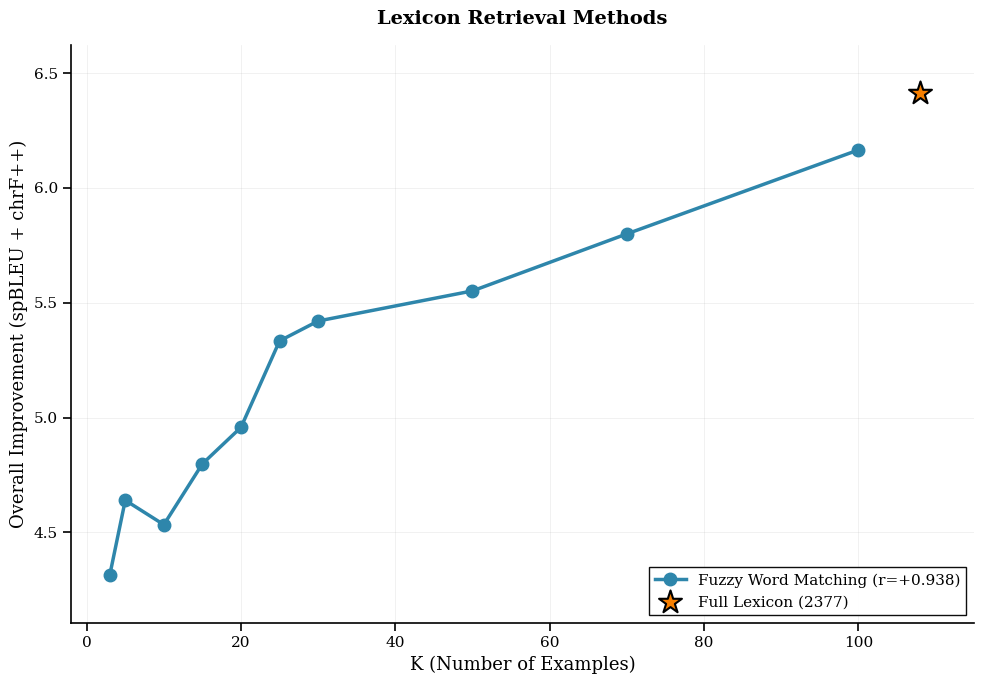


GLOSSARY RETRIEVAL PERFORMANCE SUMMARY

Correlation (N vs Improvement): r = 0.9377
Best Fuzzy Word Matching configuration: N = 100
  → Overall Improvement: Δ6.165

Full Glossary (2377 entries):
  → Overall Improvement: Δ6.413


In [12]:
# Create publication-quality visualization
fig, ax = plt.subplots(figsize=(10, 7))

# Prepare data for plotting
fuzzy_data = avg_improvement_per_config[avg_improvement_per_config['method_type'] == 'Fuzzy Word Matching'].sort_values('parameter')
full_data = avg_improvement_per_config[avg_improvement_per_config['method_type'] == 'Full']
no_lexicon_data = avg_improvement_per_config[avg_improvement_per_config['method_type'] == 'No Glossary']

# Calculate correlation
if len(fuzzy_data) > 1:
    correlation = fuzzy_data['parameter'].corr(fuzzy_data['overall_improvement'])
else:
    correlation = 0

# Plot main line: Fuzzy Word Matching method
ax.plot(fuzzy_data['parameter'], fuzzy_data['overall_improvement'], 
        marker='o', color='#2E86AB', linewidth=2.5, markersize=9,
        label=f'Fuzzy Word Matching (r={correlation:+.3f})', zorder=3)

# Add baseline (no glossary) as horizontal dashed line
if len(no_lexicon_data) > 0:
    ax.axhline(y=no_lexicon_data['overall_improvement'].iloc[0], 
               color='#E63946', linestyle='--', linewidth=2, alpha=0.8,
               label='No Lexicon Baseline', zorder=2)

# Add full glossary point as a star
if len(full_data) > 0:
    # Position star slightly to the right of the last fuzzy word point
    star_x_position = fuzzy_data['parameter'].max() + 8
    ax.scatter([star_x_position], [full_data['overall_improvement'].iloc[0]], 
               s=300, marker='*', color='#F77F00', edgecolors='black', linewidth=1.5,
               label='Full Lexicon (2377)', zorder=5)

# Axis labels and title
ax.set_xlabel('K (Number of Examples)', fontsize=13)
ax.set_ylabel('Overall Improvement (spBLEU + chrF++)', fontsize=13)
ax.set_title('Lexicon Retrieval Methods', fontsize=14, fontweight='bold', pad=15)

# Grid styling
ax.grid(True, alpha=0.25, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Legend styling
ax.legend(fontsize=11, loc='lower right', frameon=True, fancybox=False, 
         edgecolor='black', framealpha=0.95)

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# Set axis limits with some padding
ax.set_xlim(-2, fuzzy_data['parameter'].max() + 15)
y_min = min(fuzzy_data['overall_improvement'].min(), 
            no_lexicon_data['overall_improvement'].iloc[0] if len(no_lexicon_data) > 0 else float('inf'))
y_max = max(fuzzy_data['overall_improvement'].max(),
            full_data['overall_improvement'].iloc[0] if len(full_data) > 0 else 0)
y_range = y_max - y_min
ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.1 * y_range)

# Tick styling
ax.tick_params(axis='both', which='major', labelsize=11, length=6, width=1.2)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("GLOSSARY RETRIEVAL PERFORMANCE SUMMARY")
print("="*70)
print(f"\nCorrelation (N vs Improvement): r = {correlation:.4f}")
if len(fuzzy_data) > 0:
    best_n = int(fuzzy_data.loc[fuzzy_data['overall_improvement'].idxmax(), 'parameter'])
    best_improvement = fuzzy_data['overall_improvement'].max()
    print(f"Best Fuzzy Word Matching configuration: N = {best_n}")
    print(f"  → Overall Improvement: Δ{best_improvement:.3f}")

if len(full_data) > 0:
    print(f"\nFull Glossary (2377 entries):")
    print(f"  → Overall Improvement: Δ{full_data['overall_improvement'].iloc[0]:.3f}")

if len(no_lexicon_data) > 0:
    print(f"\nNo Glossary Baseline:")
    print(f"  → Overall Improvement: Δ{no_lexicon_data['overall_improvement'].iloc[0]:.3f}")
    
    if len(fuzzy_data) > 0:
        gain_over_baseline = best_improvement - no_lexicon_data['overall_improvement'].iloc[0]
        print(f"\nGain over baseline (best Fuzzy Word Matching): Δ{gain_over_baseline:.3f}")
        
print("="*70)


## 5. Detailed Metric Analysis: spBLEU and chrF++ Separately


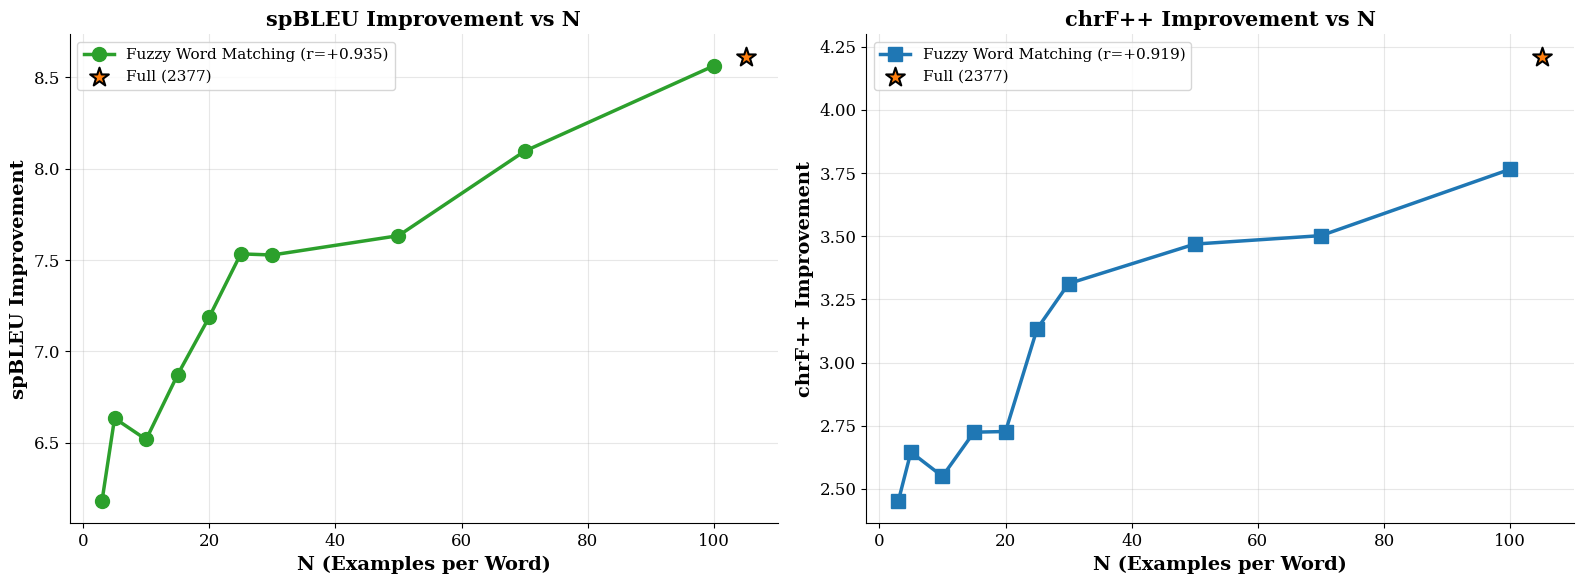


Metric-Specific Correlations:
spBLEU: r = 0.9355
chrF++: r = 0.9193


In [6]:
# Create separate plots for spBLEU and chrF++
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Prepare data
spbleu_data = df_analysis[df_analysis['metric'] == 'spbleu']
chrf_data = df_analysis[df_analysis['metric'] == 'chrf++']

# Plot 1: spBLEU
fuzzy_spbleu = spbleu_data[spbleu_data['method_type'] == 'Fuzzy Word Matching'].sort_values('parameter')
full_spbleu = spbleu_data[spbleu_data['method_type'] == 'Full']
no_glossary_spbleu = spbleu_data[spbleu_data['method_type'] == 'No Glossary']

if len(fuzzy_spbleu) > 1:
    corr_spbleu = fuzzy_spbleu['parameter'].corr(fuzzy_spbleu['improvement'])
    ax1.plot(fuzzy_spbleu['parameter'], fuzzy_spbleu['improvement'], 
             marker='o', color='#2ca02c', linewidth=2.5, markersize=10,
             label=f'Fuzzy Word Matching (r={corr_spbleu:+.3f})')

if len(no_glossary_spbleu) > 0:
    ax1.axhline(y=no_glossary_spbleu['improvement'].iloc[0], 
                color='#d62728', linestyle='--', linewidth=2, alpha=0.7,
                label='No Glossary')

if len(full_spbleu) > 0:
    ax1.scatter([fuzzy_spbleu['parameter'].max() + 5], [full_spbleu['improvement'].iloc[0]], 
                s=200, marker='*', color='#ff7f0e', edgecolors='black', linewidth=1.5,
                label='Full (2377)', zorder=5)

ax1.set_xlabel('N (Examples per Word)', fontsize=14, fontweight='bold')
ax1.set_ylabel('spBLEU Improvement', fontsize=14, fontweight='bold')
ax1.set_title('spBLEU Improvement vs N', fontsize=15, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Plot 2: chrF++
fuzzy_chrf = chrf_data[chrf_data['method_type'] == 'Fuzzy Word Matching'].sort_values('parameter')
full_chrf = chrf_data[chrf_data['method_type'] == 'Full']
no_glossary_chrf = chrf_data[chrf_data['method_type'] == 'No Glossary']

if len(fuzzy_chrf) > 1:
    corr_chrf = fuzzy_chrf['parameter'].corr(fuzzy_chrf['improvement'])
    ax2.plot(fuzzy_chrf['parameter'], fuzzy_chrf['improvement'], 
             marker='s', color='#1f77b4', linewidth=2.5, markersize=10,
             label=f'Fuzzy Word Matching (r={corr_chrf:+.3f})')

if len(no_glossary_chrf) > 0:
    ax2.axhline(y=no_glossary_chrf['improvement'].iloc[0], 
                color='#d62728', linestyle='--', linewidth=2, alpha=0.7,
                label='No Glossary')

if len(full_chrf) > 0:
    ax2.scatter([fuzzy_chrf['parameter'].max() + 5], [full_chrf['improvement'].iloc[0]], 
                s=200, marker='*', color='#ff7f0e', edgecolors='black', linewidth=1.5,
                label='Full (2377)', zorder=5)

ax2.set_xlabel('N (Examples per Word)', fontsize=14, fontweight='bold')
ax2.set_ylabel('chrF++ Improvement', fontsize=14, fontweight='bold')
ax2.set_title('chrF++ Improvement vs N', fontsize=15, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\nMetric-Specific Correlations:")
if len(fuzzy_spbleu) > 1:
    print(f"spBLEU: r = {corr_spbleu:.4f}")
if len(fuzzy_chrf) > 1:
    print(f"chrF++: r = {corr_chrf:.4f}")
